In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AffinityPropagation
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from itertools import cycle

In [2]:
dataset = pd.read_csv('Mall_Customers.csv')

In [10]:
X = dataset.iloc[:, [3,4]]
print(X)
X = dataset.iloc[:, [3,4]].values
print(X)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
print(X_std)

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]
[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 3

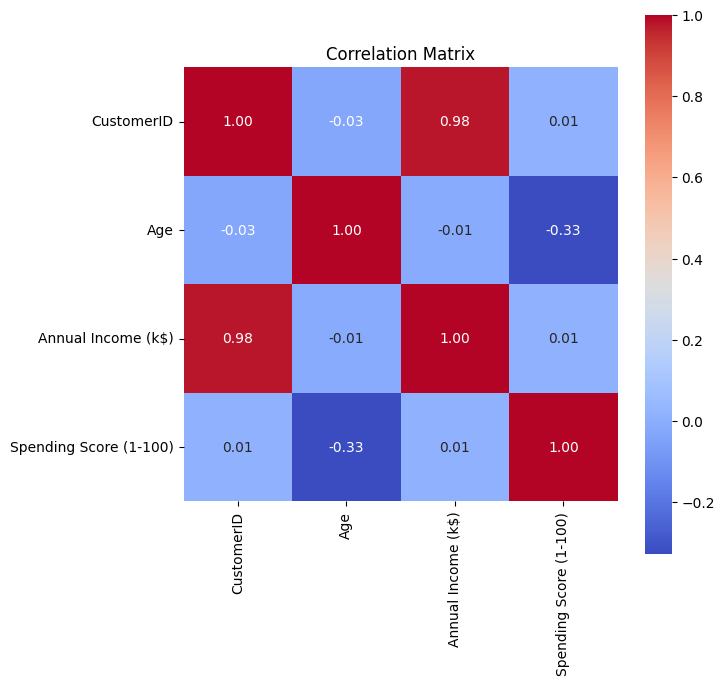

In [11]:
#Exploratory Data Analysis - helps us to gain deeper insights about the dataset which is very important in clustering
correlation_matrix = dataset.corr(numeric_only=True)
plt.figure(figsize=(7, 7))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f",square=True)
plt.title("Correlation Matrix")
plt.show()

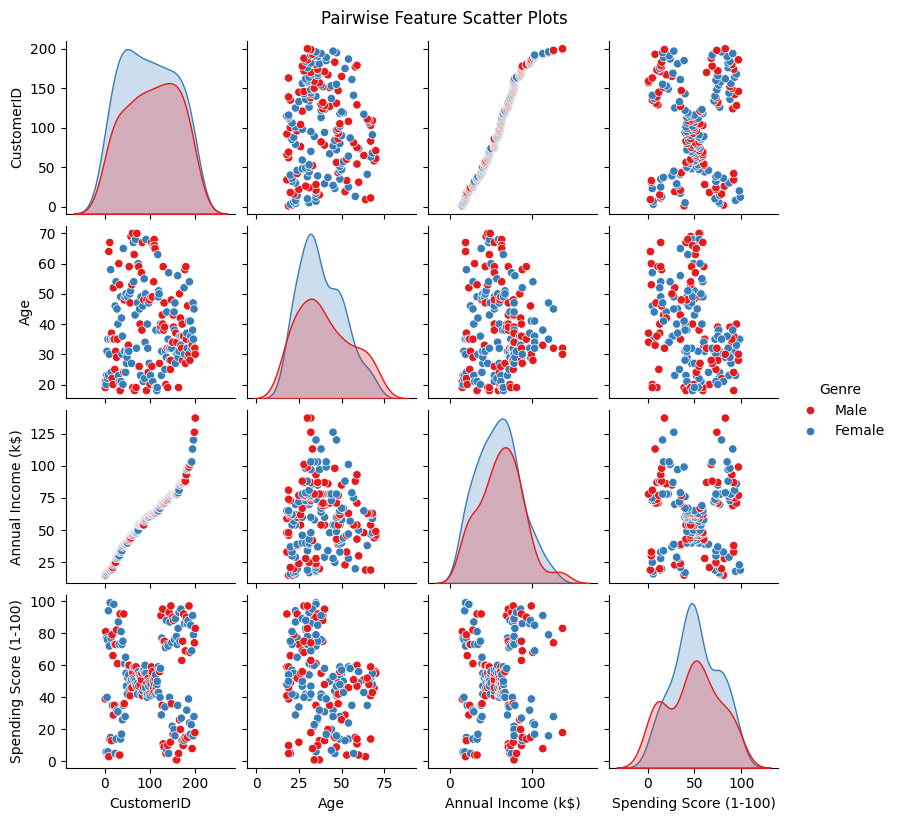

In [12]:
sns.pairplot(dataset, palette="Set1", hue="Genre", diag_kind="kde", height=2)
plt.suptitle("Pairwise Feature Scatter Plots", y=1.02)
plt.show()

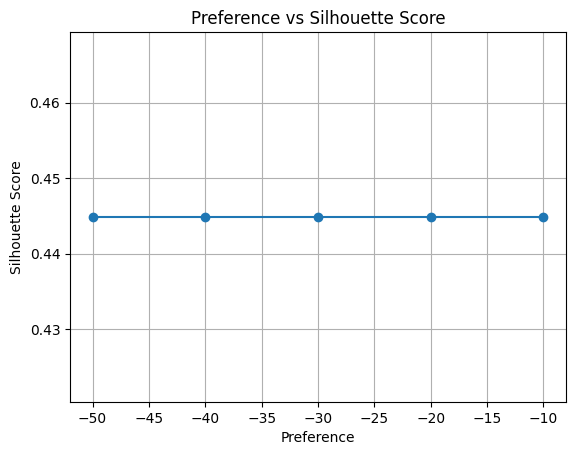

In [13]:
preference = [-50,-40,-30,-20,-10]
silhouette_scores = []
for pref in preference:
    model = AffinityPropagation(preference=preference, random_state=42)
    model.fit(X_std)
        # Evaluate only if more than one cluster is found
    if len(np.unique(model.labels_)) > 1:
        score = metrics.silhouette_score(X_std, model.labels_)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(np.nan)

plt.plot(preference, silhouette_scores, marker='o')
plt.title('Preference vs Silhouette Score')
plt.xlabel('Preference')
plt.ylabel('Silhouette Score')
plt.grid()
plt.show()

In [14]:
print(silhouette_scores)

[np.float64(0.44487855818367966), np.float64(0.44487855818367966), np.float64(0.44487855818367966), np.float64(0.44487855818367966), np.float64(0.44487855818367966)]


In [15]:
print(np.nan)

nan


In [16]:
af = AffinityPropagation(preference=-30, max_iter=50, damping=0.7,
                         random_state=42, convergence_iter=20).fit(X_std)

cluster_labels = af.labels_
print("Cluster labels:", cluster_labels)

Cluster labels: [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 2 1 2 2 0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4]


In [17]:
silhouette_score = metrics.silhouette_score(X_std, cluster_labels)
print(f"Silhouette Score: {silhouette_score:.4f}")

Silhouette Score: 0.5530


In [18]:
y_pred = af.fit_predict(X_std)

In [19]:
print(y_pred)

[0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 2 1 2 2 0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4]


In [20]:
supervised = pd.DataFrame(dataset)

In [21]:
supervised['Cluster_group'] = y_pred

In [22]:
supervised.to_csv("Affinity_cluster.csv",index=False)

C:\Users\DELL\anaconda3\envs\ml_ai\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


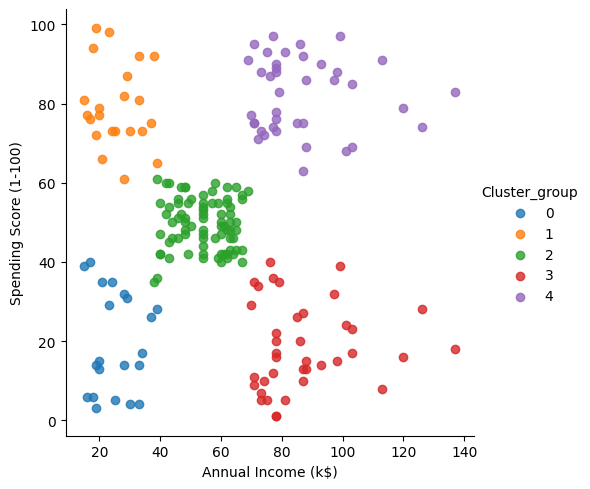

In [23]:
import seaborn as sns
facet = sns.lmplot(data=supervised, x=supervised.columns[3], y=supervised.columns[4], hue=supervised.columns[5], 
                   fit_reg=False, legend=True, legend_out=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_3852\3400446454.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(cluster_center[0], cluster_center[1], 'o',
C:\Users\DELL\AppData\Local\Temp\ipykernel_3852\3400446454.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot([cluster_center[0], x[0]], [cluster_center[1], x[1]], col, alpha=0.3)


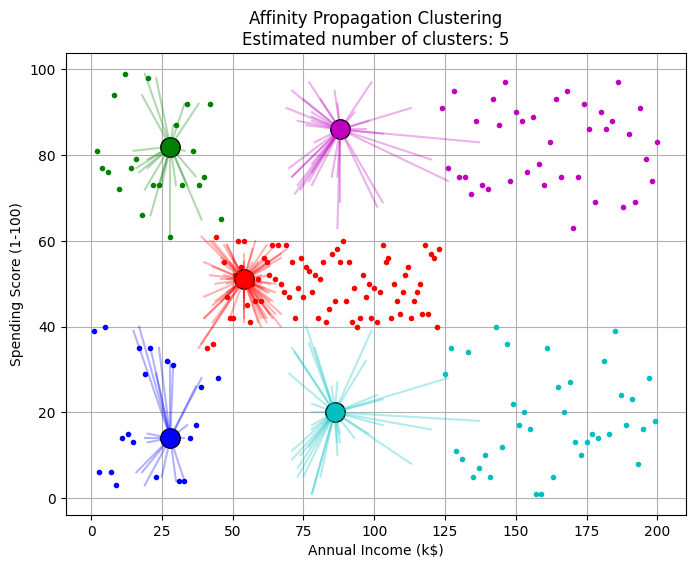

In [28]:
plt.figure(figsize=(8, 6))
colors = cycle('bgrcmyk')
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = supervised[features]

n_clusters_ = len(af.cluster_centers_indices_)
cluster_centers_indices = af.cluster_centers_indices_
labels = af.labels_

for k, col in zip(range(n_clusters_), colors):
    class_members = labels == k
    cluster_center = X.iloc[cluster_centers_indices[k]]

    plt.plot(supervised.iloc[class_members, 0], X.iloc[class_members, 1], col + '.')
    plt.plot(cluster_center[0], cluster_center[1], 'o',
             markerfacecolor=col, markeredgecolor='k', markersize=14)

    for x in X.iloc[class_members].values:
        plt.plot([cluster_center[0], x[0]], [cluster_center[1], x[1]], col, alpha=0.3)

plt.title(f'Affinity Propagation Clustering\nEstimated number of clusters: {n_clusters_}')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()